In [1]:
from polypart.algorithms import build_partition_tree
from polypart.generators import (
    get_random_arrangement,
    sample_poisson_zero_cell_polytope,
)

In [2]:
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_style("whitegrid")
%matplotlib inline

# Filtering Comparison: filtering vs no-filtering


In [9]:
def run_experiment(d, m, name, n_runs=10):
    """Run both and collect metrics."""
    results = {"filtering": [], "no-filtering": []}

    for run in range(n_runs):
        polytope = sample_poisson_zero_cell_polytope(d, 50.0, 1.0, 3)
        arrangement = get_random_arrangement(polytope, m, decimals=3)
        for filtering in [True, False]:
            start = perf_counter()
            _, n_chambers = build_partition_tree(
                arrangement,
                polytope,
                strategy="v-entropy",
                remove_redundancies=filtering,
            )
            elapsed = perf_counter() - start

            results["filtering" if filtering else "no-filtering"].append(
                {
                    "run": run,
                    "time": elapsed,
                    "n_chambers": n_chambers,
                }
            )

    return {
        "name": name,
        "filtering": pd.DataFrame(results["filtering"]),
        "no-filtering": pd.DataFrame(results["no-filtering"]),
    }

In [10]:
random_results = {}
np.random.seed(42)


for d in [2, 3, 4]:
    random_results[d] = {}
    improvements = []
    for m in [10, 20, 30]:
        print(f"Running random d={d}, m={m}...")
        result = run_experiment(d, m, f"random_d{d}_m{m}", n_runs=10)

        # 1. Get the raw arrays of times from your 10 runs
        f_times = result["filtering"][
            "time"
        ]  # Assuming this is a pandas Series or list
        nf_times = result["no-filtering"]["time"]

        # 2. Calculate improvement for each run individually
        # This gives you an array of 10 percentage values
        run_improvements = (nf_times - f_times) / nf_times * 100

        # 3. Store the mean and std of those percentages
        random_results[d][m] = {
            "mean_improvement": np.mean(run_improvements),
            "std_improvement": np.std(run_improvements),
            "raw_data": run_improvements,  # Useful if you want to make a boxplot later
        }

        improvements.append(random_results[d][m]["mean_improvement"])

    print(f"Time improvements (%) for d={d}: {improvements}")

print(random_results)

Running random d=2, m=10...
Running random d=2, m=20...
Running random d=2, m=30...
Time improvements (%) for d=2: [80.66084482957882, 84.1260579123047, 86.89637659987089]
Running random d=3, m=10...
Running random d=3, m=20...
Running random d=3, m=30...
Time improvements (%) for d=3: [84.27625095564741, 85.32152690489737, 87.40146936621177]
Running random d=4, m=10...
Running random d=4, m=20...
Running random d=4, m=30...
Time improvements (%) for d=4: [80.0555622916328, 85.66408103403587, 88.07879835046192]
{2: {10: {'mean_improvement': 80.66084482957882, 'std_improvement': 3.279357643113939, 'raw_data': 0    73.917337
1    76.407668
2    81.638668
3    80.182577
4    80.201946
5    79.528186
6    83.327639
7    82.083275
8    84.950646
9    84.370506
Name: time, dtype: float64}, 20: {'mean_improvement': 84.1260579123047, 'std_improvement': 2.3421665272457184, 'raw_data': 0    86.764612
1    80.668055
2    82.458708
3    85.726749
4    85.500848
5    79.602260
6    83.899171
7    8

In [13]:
# Save random results dict to a file
import json

for d in random_results:
    for m in random_results[d]:
        # Convert numpy arrays to lists for JSON serialization
        random_results[d][m]["raw_data"] = random_results[d][m]["raw_data"].tolist()

with open("random_results_redundancies.json", "w") as f:
    json.dump(random_results, f, indent=4)

In [15]:
# load
import json

with open("random_results_redundancies.json", "r") as f:
    loaded_random_results = json.load(f)

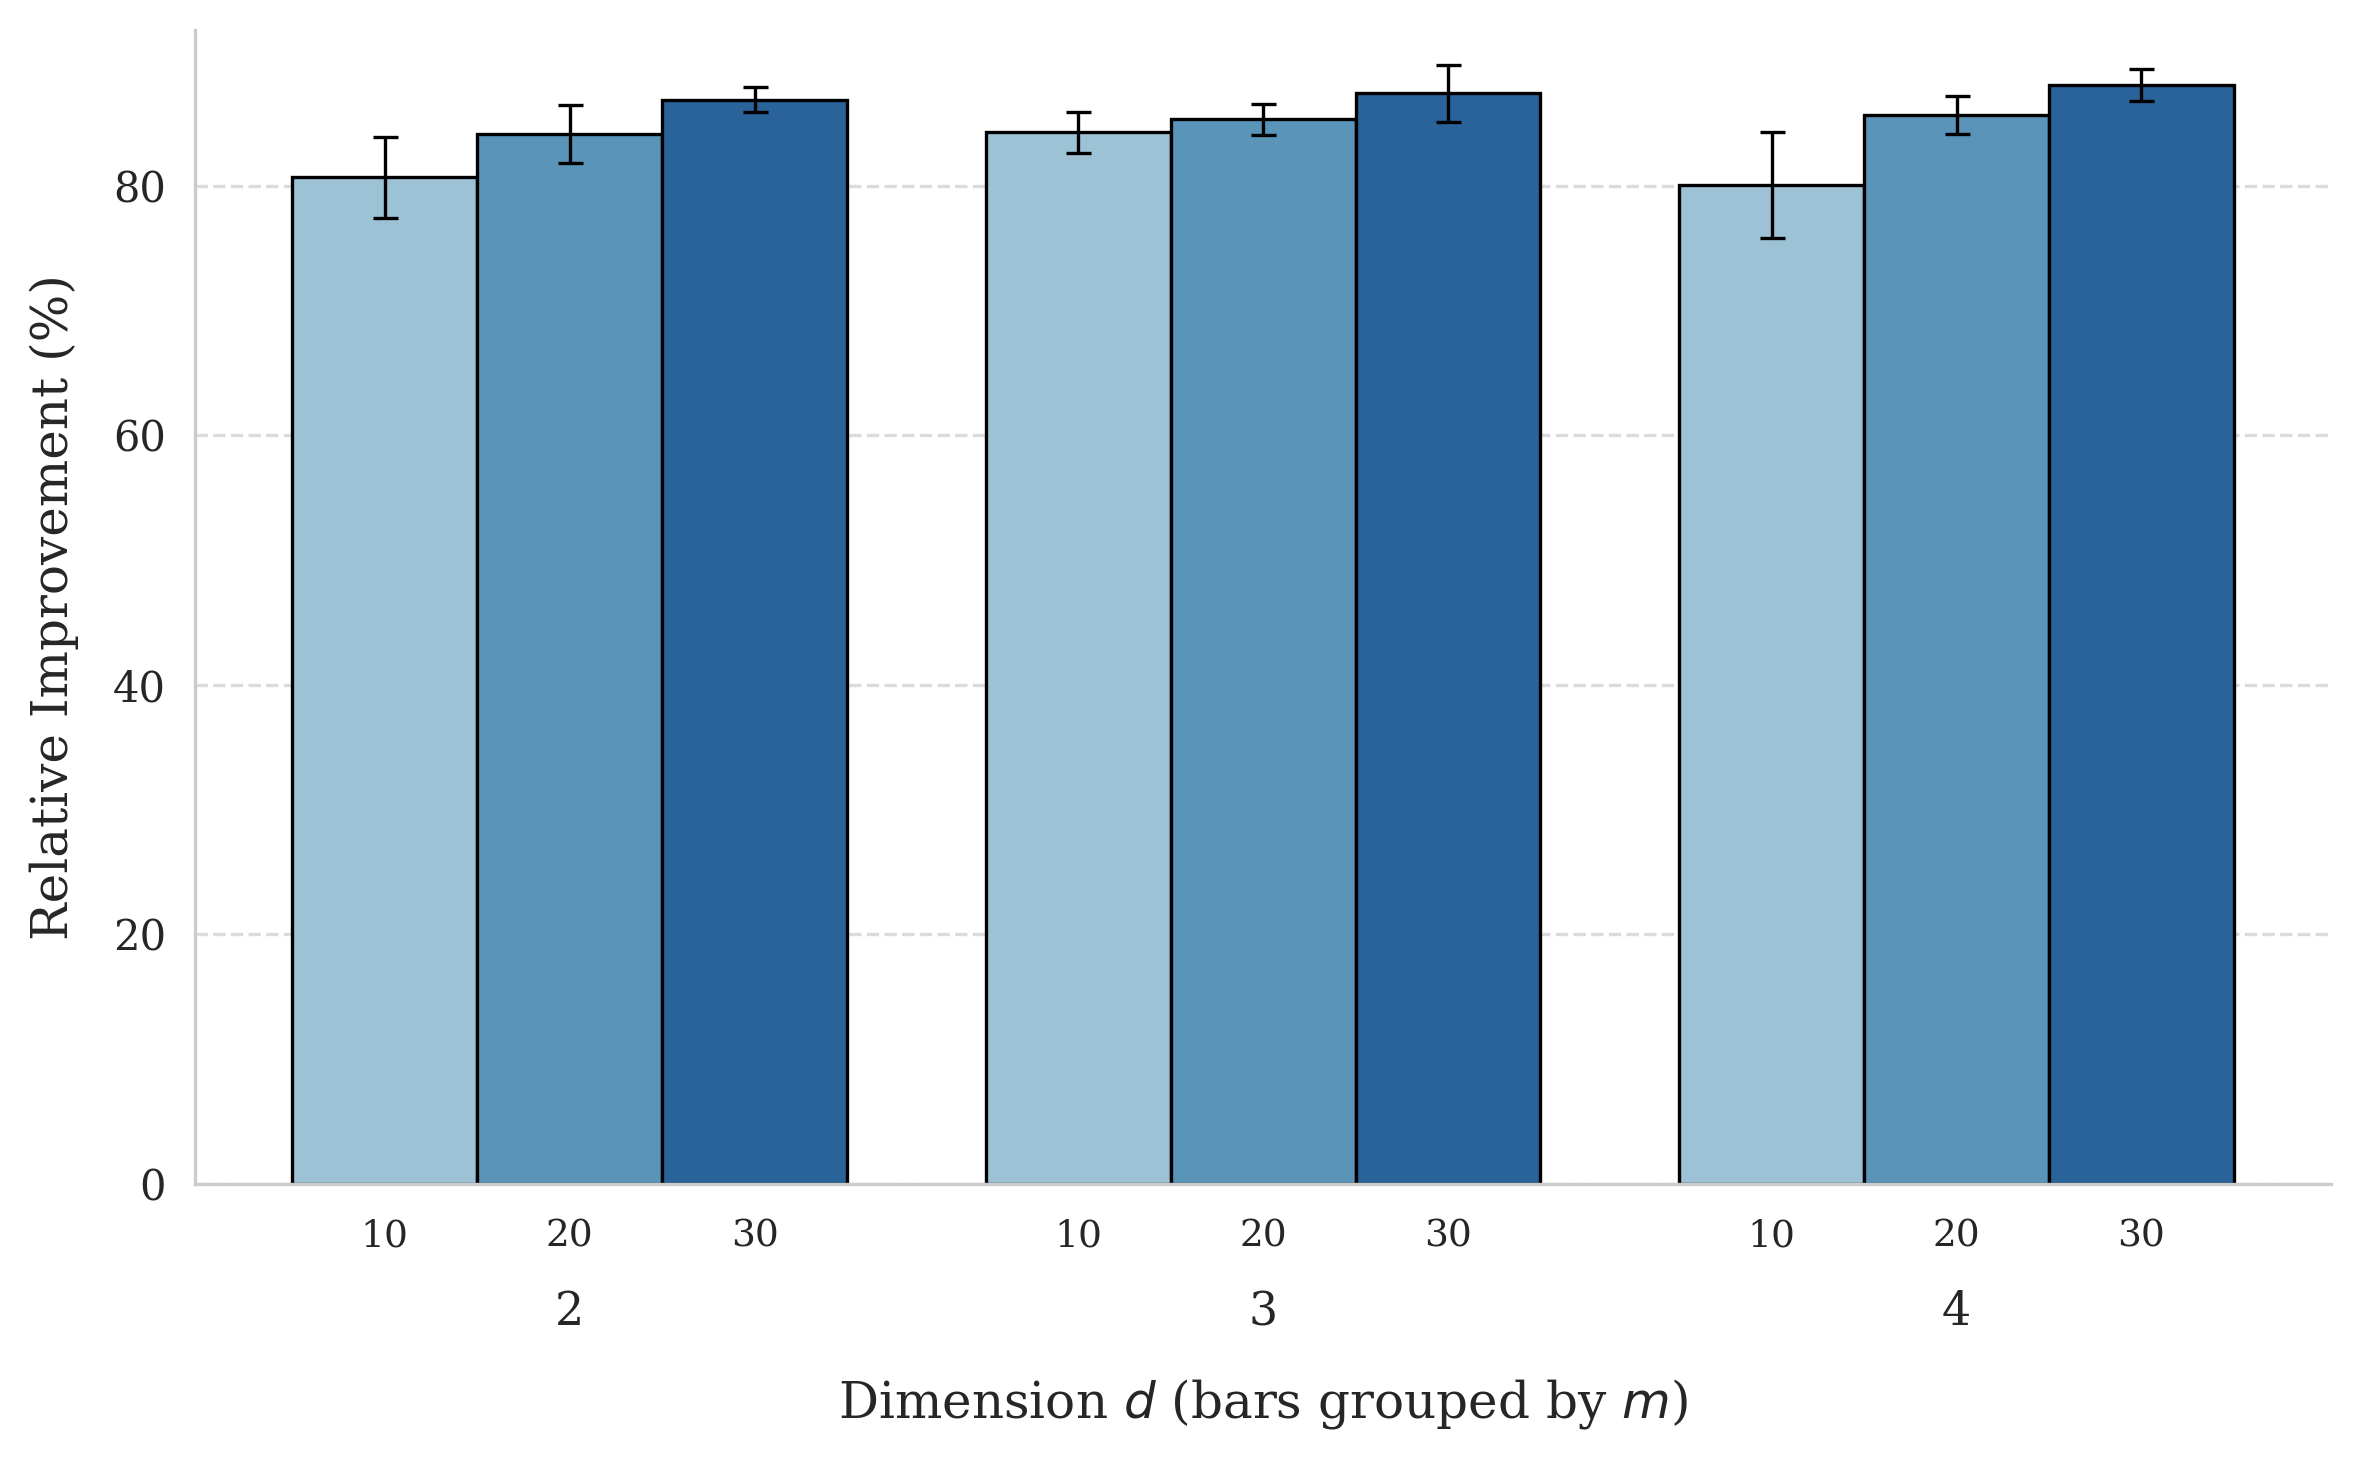

In [24]:
# Create a grouped bar chart to compare runtime improvement (positive if filtering is better)
improvement_data = []
for d in loaded_random_results:
    for m in loaded_random_results[d]:
        improvement_data.append(
            {
                "d": int(d),
                "m": int(m),
                "mean_improvement": loaded_random_results[d][m]["mean_improvement"],
                "std_improvement": loaded_random_results[d][m]["std_improvement"],
            }
        )

# 1. Convert to DataFrame and sort by d then m
df = pd.DataFrame(improvement_data).sort_values(by=["d", "m"])

# --- ACADEMIC STYLING ---
plt.rcParams.update(
    {
        "font.family": "serif",
        "axes.labelsize": 12,
        "font.size": 11,
        "xtick.labelsize": 11,
        "ytick.labelsize": 10,
        "figure.dpi": 300,
    }
)

# 2. Create a single plot for runtime improvement
fig, ax = plt.subplots(figsize=(8, 5))

# 3. Sequential Palette
unique_m = sorted(df["m"].unique())
palette = sns.color_palette("Blues", n_colors=len(unique_m) + 1)[1:]

# 4. Plot: Runtime Improvement only
sns.barplot(
    data=df,
    x="d",
    y="mean_improvement",
    hue="m",
    ax=ax,
    palette=palette,
    edgecolor="black",
    linewidth=0.8,
)
# ax.set_title("Runtime Improvement with Filtering", fontsize=13, pad=10)
ax.set_ylabel("Relative Improvement (%)", labelpad=8)
ax.set_xlabel("Dimension $d$", labelpad=8)

# 5. Set minimum baseline at 0% improvement
ax.set_ylim(bottom=0)
ax.grid(axis="y", linestyle="--", alpha=0.7)
ax.set_axisbelow(True)
ax.legend(title="m", frameon=False)

# Remove the hue legend completely
ax.get_legend().remove()

# Push the main x-axis labels (Dimension d) down to make room for m values
ax.tick_params(axis="x", which="major", pad=22)
ax.set_xlabel("Dimension $d$ (bars grouped by $m$)", labelpad=10)

# Grid and Spine clean-up
ax.grid(axis="y", linestyle="--", alpha=0.7)
ax.set_axisbelow(True)

# Iterate through the bar containers (each container is one value of 'm')
for i, container in enumerate(ax.containers):
    if i >= len(unique_m):
        break  # Safety check in case there are more containers than unique 'm' values
    m_val = unique_m[i]

    # Isolate the std_improvement values for this specific 'm',
    # sorted by 'd' to ensure they match the order of the physical bars
    std_vals = df[df["m"] == m_val].sort_values("d")["std_improvement"].values

    # Iterate through each physical bar in this group
    for j, bar in enumerate(container):
        # Calculate the exact center of the bar
        x_pos = bar.get_x() + bar.get_width() / 2
        y_pos = bar.get_height()

        # Draw the standard deviation whisker
        ax.errorbar(
            x=x_pos,
            y=y_pos,
            yerr=std_vals[j],
            fmt="none",  # Don't plot a marker, just the error bar
            color="black",
            capsize=3,  # Width of the horizontal caps
            elinewidth=0.8,  # Match the bar edge thickness
            capthick=0.8,
        )

        # Place the 'm' value directly under the bar.
        # y=-0.03 places it just below the axis line using the axis transform.
        ax.text(
            x=x_pos,
            y=-0.03,
            s=f"{m_val}",
            ha="center",
            va="top",
            fontsize=9,
            transform=ax.get_xaxis_transform(),
        )

# Final Polish
sns.despine()
plt.tight_layout()

# Save outputs
plt.savefig(
    "figures/appendix_redundancies_runtime_improvement.pdf",
    bbox_inches="tight",
    format="pdf",
)
# plt.savefig("figures/appendix_runtime_improvement.png", bbox_inches="tight", dpi=300)